In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carichiamo i pannelli solari
solar = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\zonnepanelen_lnglat.json")
print(f"Installazioni solari: {len(solar)}")
print(solar.columns.tolist())
solar.head()

Installazioni solari: 31977
['Gebruiksdoel', 'Functie', 'nl2016_installatie', 'nl2016_panelen', 'nl2016_wp', 'nl2017_installatie', 'nl2017_panelen', 'nl2017_wp', 'nl2018_installatie', 'nl2018_panelen', 'nl2018_wp', 'nl2019_installatie', 'nl2019_panelen', 'nl2019_wp', 'nl2020_installatie', 'nl2020_panelen', 'nl2020_wp', 'nl2021_installatie', 'nl2021_panelen', 'nl2021_wp', 'nl2022_installatie', 'nl2022_panelen', 'nl2022_wp', 'nl2023_installatie', 'nl2023_panelen', 'nl2023_wp', 'nl2024_installatie', 'nl2024_panelen', 'nl2024_wp', 'nl2025_installatie', 'nl2025_panelen', 'nl2025_wp', 'geometry']


,Gebruiksdoel,Functie,nl2016_installatie,nl2016_panelen,nl2016_wp,nl2017_installatie,nl2017_panelen,nl2017_wp,nl2018_installatie,nl2018_panelen,...,nl2023_installatie,nl2023_panelen,nl2023_wp,nl2024_installatie,nl2024_panelen,nl2024_wp,nl2025_installatie,nl2025_panelen,nl2025_wp,geometry
0,bijgebouw woonfunctie,Wonen,F,0,0,F,0,0,F,0,...,T,8,3280,T,8,3280,T,8,3280,POINT (5.0328 52.3074)
1,woonfunctie,Wonen,F,0,0,F,0,0,F,0,...,F,0,0,T,7,3045,T,7,3045,POINT (5.0341 52.3193)
2,woonfunctie,Wonen,F,0,0,F,0,0,F,0,...,T,6,2460,T,6,2460,T,6,2460,POINT (5.042 52.3193)
3,woonfunctie,Wonen,F,0,0,F,0,0,F,0,...,F,0,0,T,11,4785,T,11,4785,POINT (5.0417 52.3195)
4,woonfunctie,Wonen,F,0,0,F,0,0,F,0,...,T,3,1230,T,4,1665,T,4,1665,POINT (5.0397 52.3201)


In [2]:
# Vediamo la crescita delle installazioni nel tempo
anni = range(2016, 2026)
installazioni_per_anno = []
panelen_per_anno = []
wp_per_anno = []

for anno in anni:
    col_inst = f'nl{anno}_installatie'
    col_pan = f'nl{anno}_panelen'
    col_wp = f'nl{anno}_wp'
    
    installazioni_per_anno.append((solar[col_inst] == 'T').sum())
    panelen_per_anno.append(solar[col_pan].sum())
    wp_per_anno.append(solar[col_wp].sum())

crescita = pd.DataFrame({
    'Anno': list(anni),
    'Installazioni': installazioni_per_anno,
    'Panelen': panelen_per_anno,
    'Watt_picco': wp_per_anno
})

print(crescita)

   Anno  Installazioni  Panelen  Watt_picco
0  2016           3785    81902    20639304
1  2017           5434   118788    30082156
2  2018           6737   166111    44044497
3  2019           9215   258188    72129042
4  2020          11982   412351   122666660
5  2021          15442   501704   152154682
6  2022          18344   606048   192345466
7  2023          24210   764575   262497002
8  2024          30516   947099   342902802
9  2025          31977   975078   355593101


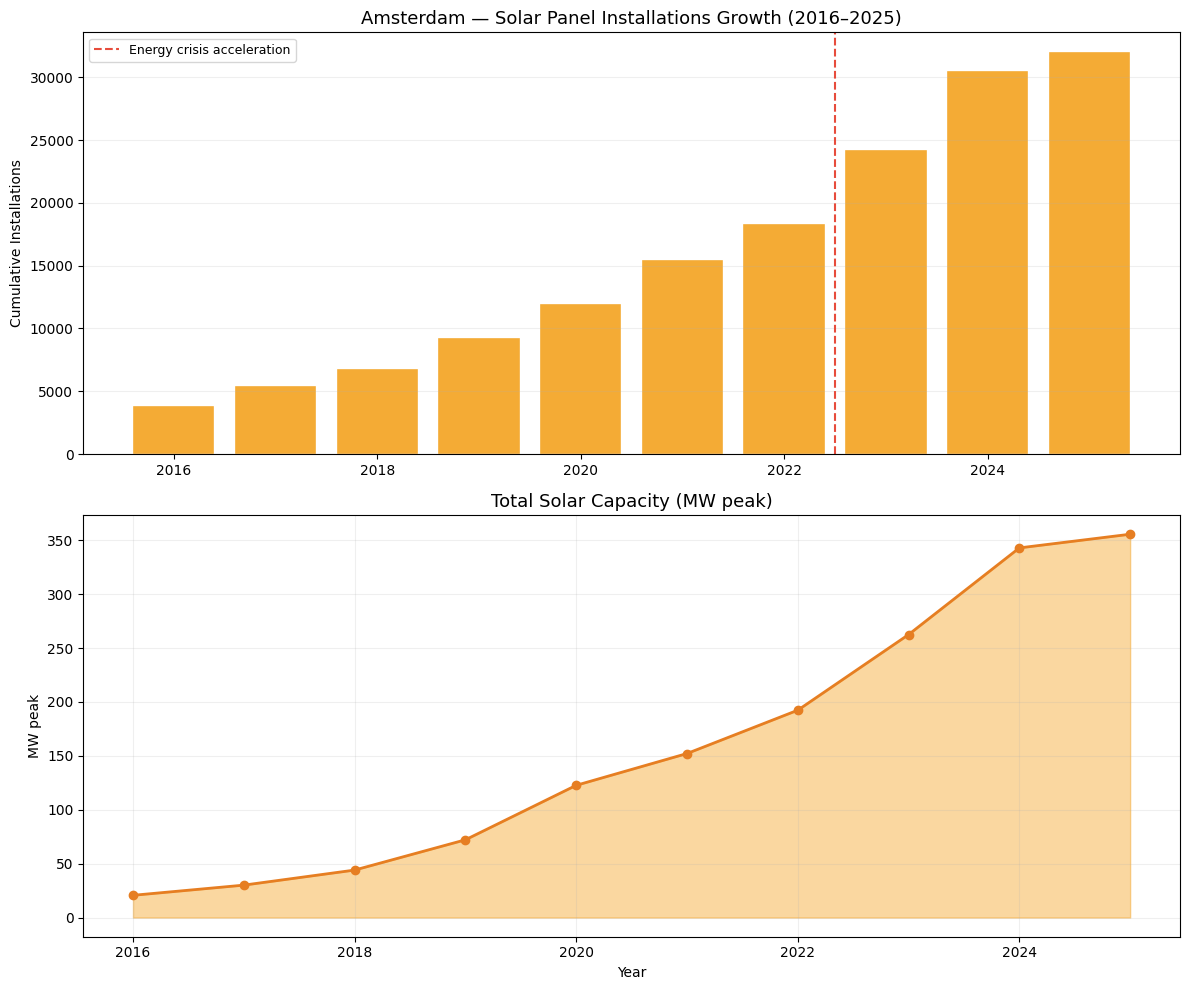

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Grafico 1 — Installazioni cumulative
ax1.bar(crescita['Anno'], crescita['Installazioni'], 
        color='#f39c12', alpha=0.85, edgecolor='white', linewidth=0.3)
ax1.set_title('Amsterdam — Solar Panel Installations Growth (2016–2025)', fontsize=13)
ax1.set_ylabel('Cumulative Installations')
ax1.grid(True, alpha=0.2, axis='y')
ax1.axvline(x=2022.5, color='#e74c3c', linestyle='--', linewidth=1.5, 
            label='Energy crisis acceleration')
ax1.legend(fontsize=9)

# Grafico 2 — Watt-picco totali
ax2.fill_between(crescita['Anno'], crescita['Watt_picco'] / 1_000_000,
                 alpha=0.4, color='#f39c12')
ax2.plot(crescita['Anno'], crescita['Watt_picco'] / 1_000_000,
         color='#e67e22', linewidth=2, marker='o', markersize=6)
ax2.set_title('Total Solar Capacity (MW peak)', fontsize=13)
ax2.set_ylabel('MW peak')
ax2.set_xlabel('Year')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('amsterdam_solar_growth.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Carichiamo le zone senza gas
gas = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\aardgasvrij_lnglat.json")
print(f"Zone aardgasvrij: {len(gas)}")
print(gas.columns.tolist())
gas.head()

Zone aardgasvrij: 475
['buurt_code', 'buurt_naam', 'toelichting', 'aandeel_kookgas', 'geometry']


,buurt_code,buurt_naam,toelichting,aandeel_kookgas,geometry
0,BU03636604,Noorder IJplas,Grotendeels onbebouwd,,"POLYGON ((4.86334 52.42948, 4.86337 52.42962, ..."
1,BU03636700,Kadoelen,All electric: gestaag aardgasvrij tussen 2020 ...,,"MULTIPOLYGON (((4.89784 52.41529, 4.89884 52.4..."
2,BU03636900,Rode Kruisbuurt,Lokale bronnetten: gestaag aardgasvrij tussen ...,,"POLYGON ((4.92483 52.39562, 4.92454 52.39526, ..."
3,BU03636910,Plan van Gool,Warmtenetbuurt: gefaseerd starten vanaf 2030,>20% van warmteaansluitingen nog op kookgas,"POLYGON ((4.92972 52.39619, 4.93178 52.3953, 4..."
4,BU03637000,Banne Zuidwest,Warmtenetbuurt: gefaseerd aardgasvrij tussen 2...,>20% van warmteaansluitingen nog op kookgas,"POLYGON ((4.90469 52.4038, 4.90471 52.40373, 4..."


In [5]:
# Estraiamo la strategia dal toelichting
gas['strategie'] = gas['toelichting'].str.extract(r'^([^:]+)', expand=False).str.strip()
print(gas['strategie'].value_counts().head(10))

strategie
Warmtenetbuurt                          200
Aardgasvrij gasnet                      121
Nieuwbouw- en transformatiegebied        33
Al (bijna) volledig op het warmtenet     33
Grotendeels onbebouwd                    32
Lokale bronnetten                        24
All electric                             18
Lokale bronnetten en warmtenet           14
Name: count, dtype: int64


In [7]:
# Carichiamo buurten
buurten = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

# Pannelli solari SENZA swap
solar_fixed = solar.copy()
solar_fixed = solar_fixed.set_crs("EPSG:4326").to_crs("EPSG:28992")

# Zone gas SENZA swap
gas_fixed = gas.copy()
gas_fixed = gas_fixed.set_crs("EPSG:4326").to_crs("EPSG:28992")

print(f"Solar bounds: {solar_fixed.total_bounds}")
print(f"Gas bounds: {gas_fixed.total_bounds}")
print(f"Buurten bounds: {buurten_proj.total_bounds}")

Solar bounds: [110491.63457387 476851.56125776 135130.04340404 493728.61882267]
Gas bounds: [110207.53982971 476830.95576152 131618.29805888 493777.16261778]
Buurten bounds: [110188.97695395 476708.7081128  135933.02464056 493893.87221555]


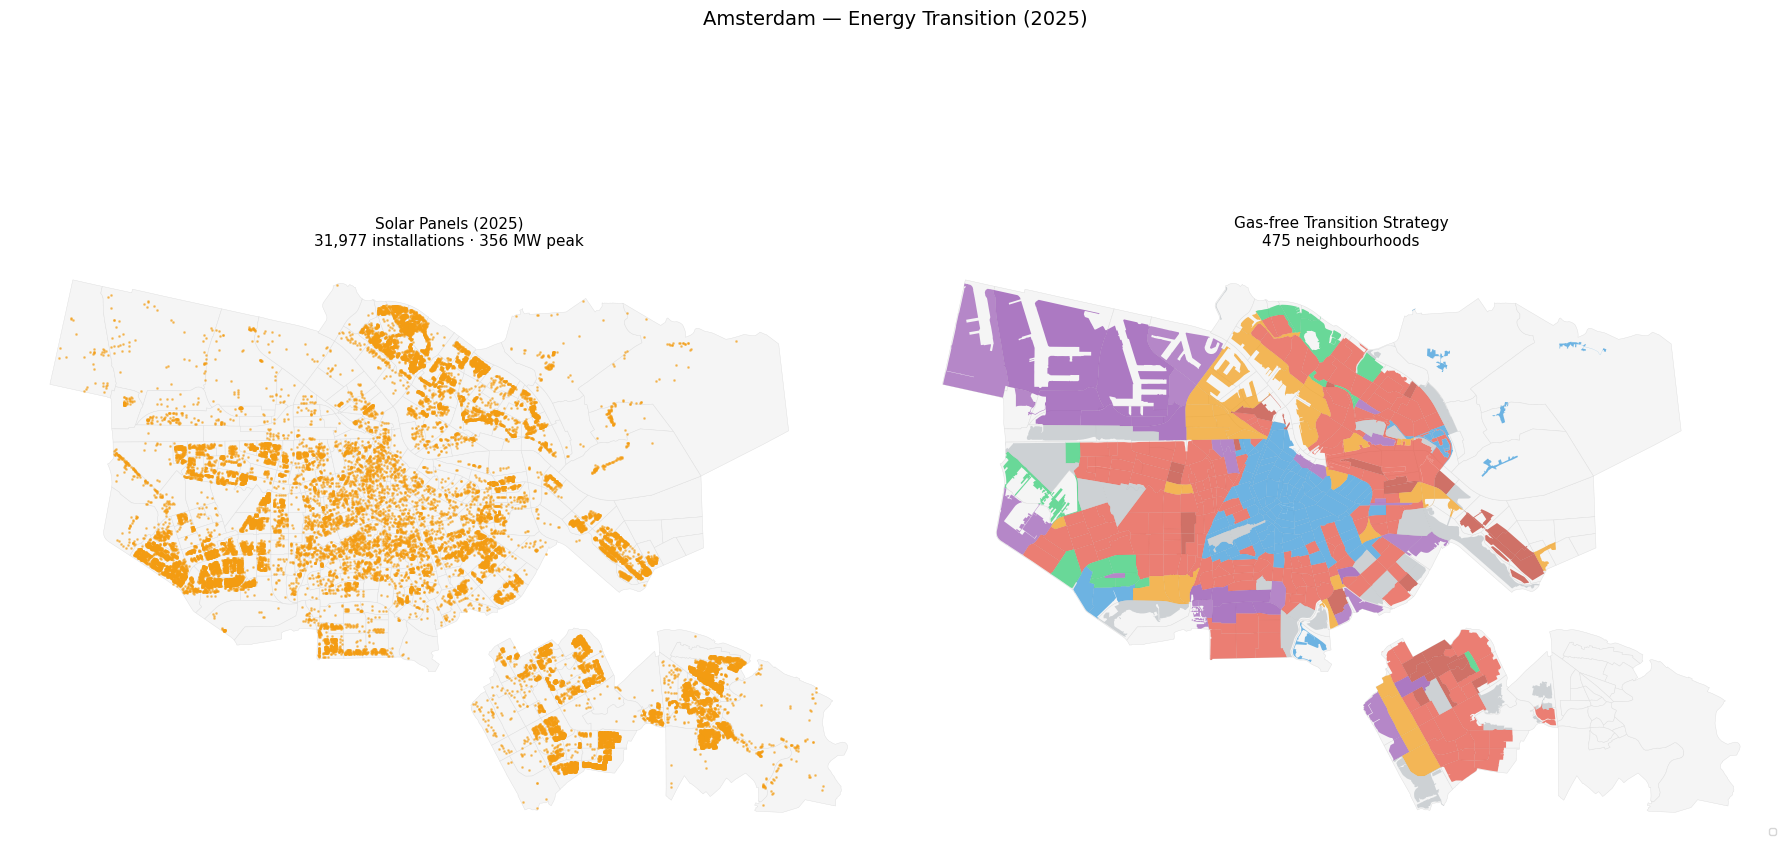

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# --- MAPPA 1: Pannelli solari 2025 ---
ax1 = axes[0]
buurten_proj.plot(ax=ax1, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Solo edifici con pannelli nel 2025
solar_2025 = solar_fixed[solar_fixed['nl2025_installatie'] == 'T'].copy()
solar_2025.plot(ax=ax1, color='#f39c12', markersize=1, alpha=0.5)

ax1.set_title(f'Solar Panels (2025)\n{len(solar_2025):,} installations · {solar_2025["nl2025_wp"].sum()/1_000_000:.0f} MW peak', fontsize=11)
ax1.set_axis_off()

# --- MAPPA 2: Zone Aardgasvrij ---
ax2 = axes[1]
buurten_proj.plot(ax=ax2, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

colori_strategia = {
    'Warmtenetbuurt': '#e74c3c',
    'Aardgasvrij gasnet': '#3498db',
    'All electric': '#2ecc71',
    'Al (bijna) volledig op het warmtenet': '#c0392b',
    'Lokale bronnetten': '#9b59b6',
    'Lokale bronnetten en warmtenet': '#8e44ad',
    'Nieuwbouw- en transformatiegebied': '#f39c12',
    'Grotendeels onbebouwd': '#bdc3c7'
}

for strategia, colore in colori_strategia.items():
    subset = gas_fixed[gas_fixed['strategie'] == strategia]
    if len(subset) > 0:
        subset.plot(ax=ax2, color=colore, alpha=0.7, label=strategia)

ax2.legend(fontsize=6, loc='lower right')
ax2.set_title(f'Gas-free Transition Strategy\n{len(gas_fixed):,} neighbourhoods', fontsize=11)
ax2.set_axis_off()

plt.suptitle('Amsterdam — Energy Transition (2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('amsterdam_energy_map.png', dpi=150, bbox_inches='tight')
plt.show()